In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import numpy as np

from nexuskan import *
from nexuskan import KAN
from nexuskan import nexusKAN

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


# grad test

$x_1 x_3 + x_2$

in: 3, out: 2

In [45]:
def some_func_to_add_dim(x, out_dim):
    x_res = torch.unsqueeze(x, dim=2)
    for i in range(out_dim - 1):
        x_res = torch.concat((x_res, torch.unsqueeze(x * 2., dim=2)), dim=2)
    
    return x_res

In [46]:
batch = 4
in_dim = 3
out_dim = 2

tau = 0.1

y_true = torch.tensor([[ -2.2, -12.2],
                       [-12.2, -42.2],
                       [ 12.3,  56.3],
                       [  7.2,  30.2]])
criterion = nn.MSELoss()

mask = torch.tensor([0.9, -0.5, 0.8]).requires_grad_(True)

x = torch.tensor([[2.0, 2.0, -2.0],
                  [3.0, -3.0, -3.0],
                  [4.0, -4.0, 4.0],
                  [4.0, -1.0, 2.0]]).requires_grad_(True)

print("x.size() =", x.size())

y = some_func_to_add_dim(x, out_dim=out_dim)

print("y.size() =", y.size())

hard_mask = torch.sigmoid(mask / tau)
print(hard_mask)

epsilon = 1e-8
sign_data = torch.sign(y + epsilon) 
selected_signs = torch.where(hard_mask[:, None] > 0.5, sign_data, 1.0)
final_sign = torch.prod(selected_signs, dim=1)

masked_y_for_prod = torch.pow(torch.abs(y), hard_mask[:, None])
y_prod = torch.prod(masked_y_for_prod, dim=1)

masked_y_for_sum = y * (1. - mask[:, None])
y = torch.sum(masked_y_for_sum, dim=1) + y_prod * final_sign

print("y.size() =", y.size())

loss = criterion(y, y_true)
loss.backward()
print(mask.grad)



x.size() = torch.Size([4, 3])
y.size() = torch.Size([4, 3, 2])
tensor([0.9999, 0.0067, 0.9997], grad_fn=<SigmoidBackward0>)
y.size() = torch.Size([4, 2])
tensor([  6.7731, -10.7224,  -2.2134])


# **Dataset** $y = x_0 x_2 + x_1$ and 1 learnable prod group

In [38]:
end_range = 1.0
start_range = -1.0
num_samples = 1000
x = (end_range - start_range) * torch.rand(num_samples + 200, 3) + start_range
# y = torch.sin(2 * torch.pi * x[:, 0]) + torch.sin(2 * torch.pi * x[:, 1])
y = x[:, 0] * x[:, 2] + x[:, 1]
# y_class = torch.where(y > 0.5, 1.0, 0.0)
dataset = {
    'train_input': x[:1000],
    'train_label': y[:1000].unsqueeze(dim=1),
    # 'train_label': y_class[:1000].unsqueeze(dim=1),
    
    'test_input': x[-200:],
    'test_label': y[-200:].unsqueeze(dim=1),
    # 'test_label': y_class[-200:].unsqueeze(dim=1),
}
dataset['train_input'] = dataset['train_input'].to(device)
dataset['train_label'] = dataset['train_label'].to(device)
dataset['test_input'] = dataset['test_input'].to(device)
dataset['test_label'] = dataset['test_label'].to(device)
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([1000, 3]), torch.Size([1000, 1]))

checkpoint directory created: ./model
saving model version 0.0


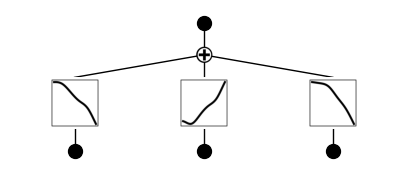

In [39]:
model = nexusKAN(width=[3, 1], grid=5, k=3, seed=42, device=device)
model(dataset['train_input'])
model.plot()

In [40]:
optimizer = optim.Adam(model.parameters(), lr=0.1)

In [41]:
criterion = nn.MSELoss()

batch_size = 512 # dataset['train_input'].shape[0]
epochs = 600

# grid_update_freq = 150

for epoch in range(epochs):
    batches = dataset['train_input'].shape[0] // batch_size
    for batch_idx in range(batches):
        if batch_idx == batches - 1:
            indices = torch.arange(batch_idx * batch_size, dataset['train_input'].shape[0])
        else:
            indices = torch.arange(batch_idx * batch_size, (batch_idx + 1) * batch_size)
        
        batch_x = dataset['train_input'][indices]
        batch_y = dataset['train_label'][indices]
        
        # if epoch % grid_update_freq == 0:
        #     model.update_grid(batch_x)
        # if (epoch + 1) % 200 == 0:
        #     for param_group in optimizer.param_groups:
        #         param_group['lr'] *= 0.8
        
        outputs = model(batch_x)
        
        train_loss = criterion(outputs, batch_y)
        
        # reg = 0.0
        lamb = 0.00001
        l1_reg = sum(torch.norm(p, 1) for p in model.parameters())
        # l1_reg = sum(torch.norm(p, 0.5) for p in model.parameters())
        loss = train_loss + lamb * l1_reg
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    with torch.no_grad():
        test_outputs = model(dataset['test_input'])
        test_loss = criterion(test_outputs, dataset['test_label'])
    
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss.item():.4f}, Test Loss: {test_loss.item():.4f}, reg: {l1_reg:.4f}')

Epoch [10/600], Train Loss: 0.0965, Test Loss: 0.0894, reg: 61.6250
Epoch [20/600], Train Loss: 0.1764, Test Loss: 0.1759, reg: 62.2713
Epoch [30/600], Train Loss: 0.0259, Test Loss: 0.0229, reg: 65.9408
Epoch [40/600], Train Loss: 0.0102, Test Loss: 0.0063, reg: 67.6662
Epoch [50/600], Train Loss: 0.0030, Test Loss: 0.0032, reg: 69.1678
Epoch [60/600], Train Loss: 0.0016, Test Loss: 0.0015, reg: 69.9132
Epoch [70/600], Train Loss: 0.0006, Test Loss: 0.0005, reg: 70.7673
Epoch [80/600], Train Loss: 0.0002, Test Loss: 0.0002, reg: 71.1190
Epoch [90/600], Train Loss: 0.0001, Test Loss: 0.0001, reg: 71.1179
Epoch [100/600], Train Loss: 0.0001, Test Loss: 0.0001, reg: 71.1854
Epoch [110/600], Train Loss: 0.0001, Test Loss: 0.0000, reg: 71.1971
Epoch [120/600], Train Loss: 0.0000, Test Loss: 0.0000, reg: 71.1682
Epoch [130/600], Train Loss: 0.0000, Test Loss: 0.0000, reg: 71.1138
Epoch [140/600], Train Loss: 0.0000, Test Loss: 0.0000, reg: 71.0592
Epoch [150/600], Train Loss: 0.0000, Test L

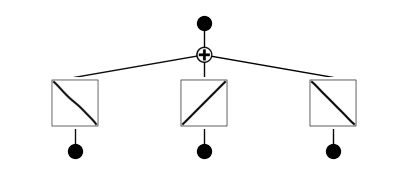

In [42]:
model.plot()

In [43]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name, param.data)

act_fun.0.coef tensor([[[-1.3279, -0.9674, -0.3148,  0.0485, -0.0137, -0.0688, -0.4357,
          -0.2968]],

        [[-1.6570, -1.1306, -0.5748, -0.1457,  0.1582,  0.3313,  0.4051,
           0.3419]],

        [[ 1.6018,  1.2941,  0.5349,  0.0514, -0.3250, -0.4824, -0.6154,
          -0.1319]]], device='cuda:0')
act_fun.0.scale_base tensor([[-1.2711],
        [ 1.0314],
        [-1.3895]], device='cuda:0')
act_fun.0.scale_sp tensor([[-0.4318],
        [ 0.6381],
        [ 0.6604]], device='cuda:0')
act_fun.0.prod_group_mask tensor([ 0.2288, -1.0857,  0.5098], device='cuda:0')
symbolic_fun.0.affine tensor([[[0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.]]], device='cuda:0')
